# Lab 1: TensorFlow Tutorial and Some Useful Functions
Welcome to the first lab in this course. Here you will see and try out some basics of TensorFlow and get familiar with some of the useful functions that you will use across the assignments. If you already know TensorFlow well, feel free to skip this notebook.

For the demonstration purposes you will use the [IMDB reviews](https://ai.stanford.edu/~amaas/data/sentiment/) dataset, on which you will perform sentiment classification. The dataset consists of 50,000 movie reviews from the Internet Movie Database ([IMDB](https://www.imdb.com/)), but has been shrinked down to 6,000 reviews to save space and ensure faster performance of the notebook.

A part of the code in this notebook is reused from the TensorFlow [official tutorial](https://www.tensorflow.org/tutorials/keras/text_classification).

## 1. Import the libraries

In [ ]:
# To silence the TensorFlow warnings, you can use the following code before you import the TensorFlow library.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = 3

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import layers
from tensorflow.keras import losses
import re
import string
import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


Setting the random seed allows you to have control over the (pseudo)random numbers. When you are working with neural networks this is a good idea, so you can get reproducible results (when you run the calculation twice you will always get the same "random" numbers). It is especially important not to mess with the random seed in your assignments, as they are used for checking whether your values are set correctly.

In [4]:
# Select your favourite number for the random seed
seed = 42

# Sets the global random seed for numpy.
np.random.seed(seed)

# Sets the global random seed for TensorFlow.
tf.random.set_seed(seed)

print(f"Random seed set to {seed}")

Random seed set to 42


## 2. Load the data
First you set the path to the directory where you store your data.

In [5]:
data_dir = './data/aclImdb'

Below, you will use the function [tf.keras.utils.text_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/text_dataset_from_directory), that generates a [tf.data.Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) from text files in a directory.
TensorFlow allows you for very easy dataset creation, provided that you have data in the following folder substructure.
```
main_directory/
... class_a/
...... a_text_1.txt
...... a_text_2.txt
... class_b/
...... b_text_1.txt
...... b_text_2.txt
```

Calling `text_dataset_from_directory(...)` will return a `tf.data.Dataset` that yields batches of texts from the subdirectories `class_a` and `class_b`, together with labels 0 and 1 (0 corresponding to class_a and 1 corresponding to class_b).

Only .txt files are supported at this time, but there are equivalent functions for different kinds of data, for example `image_dataset_from_directory` for images.

In your case you have two main directories: `./data/aclImdb/train/` and `./data/aclImdb/test/`. Within both of these two directories you have data separated in two classes: `neg` and `pos`. So your actual folder structure looks like this:

```
./data/aclImdb/train/
... neg/
...... text_1.txt
...... text_2.txt
...... ...
... pos/
...... text_1.txt
...... text_2.txt
...... ...
```
And the same for the test folder, with many .txt files in each subfolder.

You can explore the folders by clicking `File` and then `Open` in the menu above, or by clicking on the Jupyter symbol.

In the cell below, you will load the data. Note the different parameters that you can use when loading the data. For example: originally you only have the data split only to training and test sets, but you can very easily split the datasets further, by using just a few parameters.

In [7]:
# Here you have two main directories: one for train and one for test data.
# You load files from each to create training and test datasets.

# Create the training set. Use 80% of the data and keep the remaining 20% for the validation.
raw_training_set = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    validation_split = 0.2,
    subset = 'training',
    seed = seed
)

# Create the validation set. Use 20% of the data that was not used for training.
raw_validation_set = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    validation_split = 0.2,
    subset = 'validation',
    seed = seed
)


# Create the test set.
raw_test_set = tf.keras.utils.text_dataset_from_directory(
    f'{data_dir}/test',
    labels='inferred',
    label_mode='int',
    batch_size=32
)

Found 5000 files belonging to 2 classes.
Using 4000 files for training.
Found 5000 files belonging to 2 classes.
Using 1000 files for validation.
Found 5000 files belonging to 2 classes.


Check that the labels 0 and 1 correctly correspond to the negative and positive examples respectively.

In [8]:
print(f"Label 0 corresponds to {raw_training_set.class_names[0]}")
print(f"Label 1 corresponds to {raw_training_set.class_names[1]}")

Label 0 corresponds to neg
Label 1 corresponds to pos


If you want to look at a small subset of your dataset, you can use `.take()` method, by passing it the `count` parameter. The method returns a new dataset of the size at most `count`, where `count` is the number of batches. You can read more about `tf.data.Dataset` and the `take` method [here](https://www.tensorflow.org/api_docs/python/tf/data/Dataset).

In [9]:
# Take one batch from the dataset and print out the first three datapoints in the batch
for text_batch, label_batch in raw_training_set.take(1):
    for i in range(3):
        print(f'Review: \n{text_batch.numpy()[i]}')
        print(f'Label:{label_batch.numpy()[i]}\n')

Review: 
b'This is a reunion, a team, and a great episode of Justice. From hesitation to resolution, Clark has made a important leap from a troubled teenager who was afraid of a controlled destiny, to a Superman who, like Green Arrow, sets aside his emotions to his few loved ones, ready to save the whole planet. This is not just a thrilling story about teamwork, loyalty, and friendship; this is also about deciding what\'s more important in life, a lesson for Clark. I do not want the series to end, but I hope the ensuing episodes will strictly stick to what Justice shows without any "rewind" pushes and put a good end here of Smallville---and a wonderful beginning of Superman.<br /><br />In this episode, however, we should have seen more contrast between Lex and the Team. Nine stars should give it enough credit.'
Label:1

Review: 
b'"Hey Babu Riba" is a film about a young woman, Mariana (nicknamed "Esther" after a famous American movie star), and four young men, Glenn, Sacha, Kicha, and 

## 3. Prepare the Data

Now that you have seen how the dataset looks like, you need to prepare it in the format that a neural network understands. For this, you will use the [tf.keras.layers.TextVectorization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) layer.

This layer converts text to vectors that can then be fed to a neural network. A very useful feature is that you can pass it another function that performs custom standardization of text. This includes lowercasing the text, removing punctuation and/or HTML elements, web links or certain tags. This is very important, as every dataset requires different standardization, depending on its contents. After the standardization, the layer tokenizes the text (splits into words) and vectorizes it (converts from words to numbers) so that it can be fed to the neural network. The `output_sequence_length` is set to 250, which means that the layer will pad shorter sequences or truncate longer sequences, so they will al have the same length. This is done so that all the inout vectors are the same length and can be nicely put together into matrices.

In [12]:
# Set the maximum number of words
max_features = 1000

# Define the custom standardization function
def custom_standardization(input_data):
    # Convert all text to lowercase
    lowercase = tf.strings.lower(input_data)

    # remove HTML tags
    strpped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')

    # Remove punctuation
    replaced = tf.strings.regex_replace(strpped_html, '[%s]'%re.escape(string.punctuation),'')

    return replaced


In [13]:
# Create a layer that you can use to convert text to vectors
vectorize_layer = layers.TextVectorization(
    standardize = custom_standardization,
    max_tokens = max_features,
    output_mode = 'int',
    output_sequence_length = 250
)

Next, you call adapt to fit the state of the preprocessing layer to the dataset. This will cause the model to build a vocabulary (an index of strings to integers). If you want to access the vocabulary, you can call the .get_vocabulary() on the layer.

In [14]:
# Build the vocabulary
train_text = raw_training_set.map(lambda x, y: x)

vectorize_layer.adapt(train_text)

# Print out the vocabulary size
print(f"Vocabulary size: {len(vectorize_layer.get_vocabulary())}")

Vocabulary size: 1000


Now you can define the final function that you will use to vectorize the text and see what it looks like.

Note that you need to add the `.expand_dims()`. This adds another dimension to your data and is very commonly used when processing data to add an additional dimension to accomodate for the batches.

In [17]:
# Define the final function that you will use to vectorize the text.
def vectorize_text(text, label):
    text = tf.expand_dims(text,-1)
    return vectorize_layer(text), label

In [19]:
# Get one batch and select the first datapoint
text_batch, label_batch = next(iter(raw_training_set))
first_review, first_label = text_batch[0], label_batch[0]

# Show the raw data
print(f"Review:\n{first_review}")
print(f"\nLabel: {raw_training_set.class_names[first_label]}")
# Show the vectorized data
print(f"\nVectorized review\n{vectorize_text(first_review, first_label)}")

Review:
b"The first half was OK, but the last half really, really disappointed. It's funny the producers even admitted they didn't have a clue for the ending, and it really showed. Whats really sad is i have to write ten lines of comment minimum to be able to post this. I really didn't want to include spoilers to qualify my remarks since the show isn't really worth that effort. When Battlestar galatica first came out I was really excited with the prospect of a better remake, it didn't happen that first season border on being space porn. They eventually cleaned it up a bit and actually had some pretty fair drama, so I started watching again. But to end the series with kara being a cyclon god angel, same with baltar and six was pretty dumb."

Label: neg

Vectorized review
(<tf.Tensor: shape=(1, 250), dtype=int64, numpy=
array([[  2,  84, 323,  13, 659,  18,   2, 213, 323,  63,  63, 725,  29,
        160,   2,   1,  54,   1,  34, 152,  25,   3,   1,  15,   2, 259,
          4,   9,  63,  

Now you can apply the vectorization function to vectorize all three datasets.

In [21]:
train_ds = raw_training_set.map(vectorize_text)
val_ds = raw_validation_set.map(vectorize_text)
test_ds = raw_test_set.map(vectorize_text)

### Configure the Dataset

There are two important methods that you should use when loading data to make sure that I/O does not become blocking.

`.cache()` keeps data in memory after it's loaded off disk. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache, which is more efficient to read than many small files.

`.prefetch()` overlaps data preprocessing and model execution while training.

You can learn more about both methods, as well as how to cache data to disk in the [data performance guide](https://www.tensorflow.org/guide/data_performance).

For very interested, you can read more about `tf.data` and `AUTOTUNE` in this [paper](https://vldb.org/pvldb/vol14/p2945-klimovic.pdf), but be aware that this is already very advanced information about how TensorFlow works.

In [22]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 4. Create a Sequential Model

A [Sequential model](https://www.tensorflow.org/guide/keras/sequential_model) is appropriate for a simple stack of layers where each layer has exactly one input tensor and one output tensor (layers follow each other in a sequence and there are no additional connections).

Here you will use a Sequential model using only three layers:
 - An [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer. This layer takes the integer-encoded reviews and looks up an embedding vector for each word-index. These vectors are learned as the model trains. The vectors add a dimension to the output array. The resulting dimensions are: (batch, sequence, embedding).
 - A [GlobalAveragePooling1D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling1D) layer returns a fixed-length output vector for each example by averaging over the sequence dimension. This allows the model to handle input of variable length, in the simplest way possible.
 - A [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) layer with a single output node.

In [23]:
embedding_dim = 16

# Create the model by calling tf.keras.Sequential, where the layers are given in a list.
model_sequential = tf.keras.Sequential([
    layers.Embedding(max_features, embedding_dim),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1, activation = 'sigmoid')
])

# Print out the summary of the model
model_sequential.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 16)          16000     
                                                                 
 global_average_pooling1d (G  (None, 16)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 16,017
Trainable params: 16,017
Non-trainable params: 0
_________________________________________________________________


Compile the model. Choose the loss function, the optimizer and any additional metrics you want to calculate. Since this is a binary classification problem you can use the [losses.BinaryCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) loss function.

In [24]:
model_sequential.compile(loss = losses.BinaryCrossentropy(from_logits=True), optimizer='adam', metrics=['accuracy'])

## 5. Create a Model Using Functional API

You can use the [functional API](https://www.tensorflow.org/guide/keras/functional_api) when you want to create more complex models, but it works just as well for the simple models like the one above. The functional API can handle models with non-linear topology, shared layers, and even multiple inputs or outputs.

The biggest difference at the first glance is that you need to explicitly state the input. Then you use the layers as functions and pass previous layers as parameters into the functions. In the end you build a model, where you pass it the input and the output of the neural network. All of the information from between them (hidden layers) is already hidden in the output layer (remember how each layer takes the previous layer in as a parameter).

In [25]:
embedding_dim = 16

# Define the inputs
inputs = tf.keras.Input(shape = (None, ))

# Define the first layer
embedding = layers.Embedding(max_features, embedding_dim)
# Call the first layer with inputs as the parameter
x = embedding(inputs)

# Define the second layer
pooling = layers.GlobalAveragePooling1D()
# Call the first layer with the output of the previous layer as the parameter
x = pooling(x)

# Define and call in the same line. (Same thing used two lines of code above
# for other layers. You can use any option you prefer.)
# outputs = layers.Dense(1, activation='sigmoid')(x)
#The two-line alternative to the one layer would be:
dense = layers.Dense(1, activation='sigmoid')
outputs = dense(x)

# Create the model
model_functional = tf.keras.Model(inputs = inputs, outputs = outputs)

# Print out the summary of the model
model_functional.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None)]            0         
                                                                 
 embedding_1 (Embedding)     (None, None, 16)          16000     
                                                                 
 global_average_pooling1d_1   (None, 16)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 16,017
Trainable params: 16,017
Non-trainable params: 0
_________________________________________________________________


Compile the model: choose the loss, optimizer and any additional metrics you want to calculate. This is the same as for the sequential model.

In [26]:
model_functional.compile(loss = losses.BinaryCrossentropy(from_logits=True), optimizer='adam', metrics = ['accuracy'])

## 6. Train the Model

Above, you have defined two different models: one with a functional api and one sequential model. From now on, you will use only one of them. feel free to change which model you want to use in the next cell. The results should be the same, as the architectures of both models are the same.

In [27]:
# Select which model you want to use and train. the results should be the same
model = model_functional # model = model_sequential

Now you will train the model. You will pass it the training and validation dataset, so it can compute the accuracy metric on both during training.

In [28]:
epochs = 25
history = model.fit(
    train_ds, 
    validation_data = val_ds,
    epochs = epochs,
    verbose = 2
)

Epoch 1/25


c:\Users\mrinm\anaconda3\envs\NLP_env\lib\site-packages\tensorflow\python\util\dispatch.py:1082: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


125/125 - 2s - loss: 0.6912 - accuracy: 0.5780 - val_loss: 0.6888 - val_accuracy: 0.6210 - 2s/epoch - 13ms/step
Epoch 2/25
125/125 - 0s - loss: 0.6843 - accuracy: 0.6758 - val_loss: 0.6790 - val_accuracy: 0.6920 - 373ms/epoch - 3ms/step
Epoch 3/25
125/125 - 0s - loss: 0.6714 - accuracy: 0.6980 - val_loss: 0.6627 - val_accuracy: 0.7230 - 361ms/epoch - 3ms/step
Epoch 4/25
125/125 - 0s - loss: 0.6529 - accuracy: 0.7175 - val_loss: 0.6417 - val_accuracy: 0.7500 - 361ms/epoch - 3ms/step
Epoch 5/25
125/125 - 0s - loss: 0.6311 - accuracy: 0.7330 - val_loss: 0.6188 - val_accuracy: 0.7550 - 356ms/epoch - 3ms/step
Epoch 6/25
125/125 - 0s - loss: 0.6079 - accuracy: 0.7477 - val_loss: 0.5960 - val_accuracy: 0.7670 - 371ms/epoch - 3ms/step
Epoch 7/25
125/125 - 0s - loss: 0.5846 - accuracy: 0.7602 - val_loss: 0.5741 - val_accuracy: 0.7790 - 391ms/epoch - 3ms/step
Epoch 8/25
125/125 - 0s - loss: 0.5620 - accuracy: 0.7730 - val_loss: 0.5536 - val_accuracy: 0.7800 - 393ms/epoch - 3ms/step
Epoch 9/25
12

Now you can use `model.evaluate()` to evaluate the model on the test dataset.

In [29]:
loss, accuracy = model.evaluate(test_ds)

print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

157/157 [==============================] - 1s 5ms/step - loss: 0.4009 - accuracy: 0.8230
Loss: 0.4009421169757843
Accuracy: 0.8230000138282776


When you trained the model, you saved the history in the history variable. Here you can access a dictionary that contains everything that happened during the training. In your case it saves the losses and the accuracy on both training and validation sets. You can plot it to gain some insights into how the training is progressing.

In [30]:
def plot_metrics(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric.title())
    plt.legend([metric, f'val_{metric}'])
    plt.show()

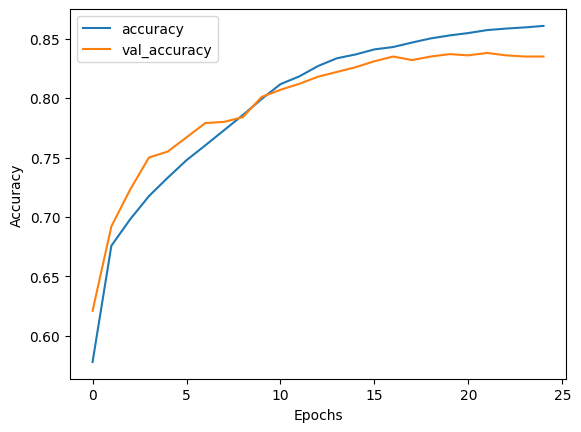

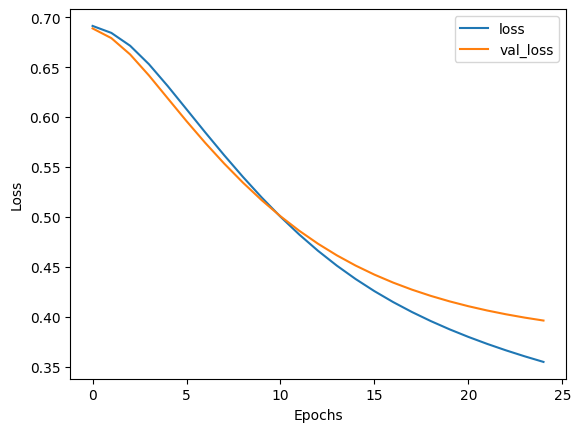

In [31]:
plot_metrics(history, "accuracy")
plot_metrics(history, "loss")

You can see that after 25 epochs, the training accuracy still goes up, but the validation accuracy already plateaus at around 86%. On the other hand both training and validation losses are still decreasing, which means that while the model does not learn to predict more cases accurately, it still gets more confident in its predictions. Here you used the simplest possible model: you have used embeddings, averaging layer and a dense layer with one output. You can try different architectures to see if the model improves. Perhaps you can add some dropout layers to reduce the chance of overfitting, or you can try a completely different architecture, like using convolutional layers or reccurent layers. You will learn a lot more about recurrent neural networks in the later weeks of this course.

## 7. Predict on Your Own Data

Finally, you can use the model to predict on any new data you may have. You can use it to predict the sentiment of examples in the test dataset (which the model has not seen in the training process) or use some completely new examples.

Here you will expand your model to be able to predict on raw strings (rather than on vectorized examples). Previously, you applied the TextVectorization layer to the dataset before feeding it to the model. To simplify deploying the model, you can include the TextVectorization layer inside your model and then predict on raw strings. To do so, you can create a new sequential model where you merge the vectorization layer with your trained model using the weights you just trained.

In [32]:
# Make a new sequential model using the vectorization layer and the model you just trained.
export_model = tf.keras.Sequential([
    vectorize_layer, 
    model
])

# Compile the model
export_model.compile(loss = losses.BinaryCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy'])

Now you can use this model to predict on some of your own examples. You can do it simply by calling `model.predict()`

In [33]:
examples = ['this movie was very, very good', 'quite ok', 'the movie was not bad', 'bad', 
            'negative disappointed bad scary', 'this movie was stupid']

results = export_model.predict(examples, verbose=False)

for result, example in zip(results, examples):
    print(f'Result: {result[0]:.3f},   Label: {int(np.round(result[0]))},   Review: {example}')

Result: 0.597,   Label: 1,   Review: this movie was very, very good
Result: 0.507,   Label: 1,   Review: quite ok
Result: 0.392,   Label: 0,   Review: the movie was not bad
Result: 0.433,   Label: 0,   Review: bad
Result: 0.371,   Label: 0,   Review: negative disappointed bad scary
Result: 0.424,   Label: 0,   Review: this movie was stupid


# Vanilla RNNs and GRUs

In this notebook, you will learn how to define the forward method for vanilla RNNs and GRUs from scratch in `NumPy`. After this, you will create a full neural network with GRU layers using tensorflow.

By completing this notebook, you will:

- Be able to define the forward method for vanilla RNNs and GRUs
- Be able to build a sequential model using recurrent layers in tensorflow
- Be able to use the `return_sequences` parameter in recurrent layers

In [1]:
import numpy as np
from time import perf_counter
import tensorflow as tf

In [2]:
def sigmoid(x): # Sigmoid function
    return 1.0 / (1.0 + np.exp(-x))

# Part 1: Forward method for vanilla RNNs and GRUs using `numpy`

In this part of the notebook, you'll see the implementation of the forward method for a vanilla RNN and you'll implement that same method for a GRU. For this exercise you'll use a set of random weights and variables with the following dimensions:

- Embedding size (`emb`) : 128
- Hidden state size (`h_dim`) : 16

The weights `w_` and biases `b_` are initialized with dimensions (`h_dim`, `emb + h_dim`) and (`h_dim`, 1). We expect the hidden state `h_t` to be a column vector with size (`h_dim`,1) and the initial hidden state `h_0` is a vector of zeros.

In [3]:
np.random.seed(10)              # Random seed, so your results match ours
emb = 128                       # Embedding size
T = 256                         # Length of sequence
h_dim = 16                      # Hidden state dimension
h_0 = np.zeros((h_dim, 1))      # Initial hidden state

# Random initialization of weights (w1, w2, w3) and biases (b1, b2, b3)
w1 = np.random.standard_normal((h_dim, emb + h_dim))
w2 = np.random.standard_normal((h_dim, emb + h_dim))
w3 = np.random.standard_normal((h_dim, emb + h_dim))
b1 = np.random.standard_normal((h_dim, 1))
b2 = np.random.standard_normal((h_dim, 1))
b3 = np.random.standard_normal((h_dim, 1))

# Random initialization of input X
# Note that you add the third dimension (1) to achieve the batch representation.
X = np.random.standard_normal((T, emb, 1))

# Define the lists of weights as you will need them for the two different layers
weights_vanilla = [w1, b1]
weights_GRU = [w1.copy(), w2, w3, b1.copy(), b2, b3]

Note that you are creating two lists where you are storing all the weights. You can see that the vanilla recurrent neural network uses a much smaller subset of weights than GRU. Since you will not be updating any weights in this lab, it is ok to define them in a list like above.

## 1.1 Forward method for vanilla RNNs

The vanilla RNN cell is quite straight forward. Its most general structure is presented in the next figure: 

<img src="images/RNN.PNG" width="400"/>

As you saw in the lecture videos and in the other lab, the computations made in a vanilla RNN cell are equivalent to the following equations:

\begin{equation}
h^{<t>}=g(W_{h}[h^{<t-1>},x^{<t>}] + b_h)
\end{equation}
    
\begin{equation}
\hat{y}^{<t>}=g(W_{yh}h^{<t>} + b_y)
\end{equation}

where $[h^{<t-1>},x^{<t>}]$ means that $h^{<t-1>}$ and $x^{<t>}$ are concatenated together. In the next cell you have the implementation of the forward method for a vanilla RNN. 

In [4]:
def forward_V_RNN(inputs, weights): # Forward propagation for a a single vanilla RNN cell
    x, h_t = inputs

    # weights.
    wh, bh = weights

    # new hidden state
    h_t = np.dot(wh, np.concatenate([h_t, x])) + bh
    h_t = sigmoid(h_t)
    
    # We avoid implementation of y for clarity
    y = h_t
    
    return y, h_t

As you can see, we omitted the computation of $\hat{y}^{<t>}$. This was done for the sake of simplicity, so you can focus on the way that hidden states are updated here and in the GRU cell.

A GRU cell has many more computations than vanilla RNN cells. You can see this visually in the following diagram:

<img src="images/GRU.PNG" width="400"/>

As you saw in the lecture videos, GRUs have relevance $\Gamma_r$ and update $\Gamma_u$ gates that control how the hidden state $h^{<t>}$ is updated on every time step. With these gates, GRUs are capable of keeping relevant information in the hidden state even for long sequences. The equations needed for the forward method in GRUs are provided below: 

\begin{equation}
\Gamma_r=\sigma{(W_r[h^{<t-1>}, x^{<t>}]+b_r)}
\end{equation}

\begin{equation}
\Gamma_u=\sigma{(W_u[h^{<t-1>}, x^{<t>}]+b_u)}
\end{equation}

\begin{equation}
c^{<t>}=\tanh{(W_h[\Gamma_r*h^{<t-1>},x^{<t>}]+b_h)}
\end{equation}

\begin{equation}
h^{<t>}=\Gamma_u*c^{<t>}+(1-\Gamma_u)*h^{<t-1>}
\end{equation}

In the next cell, you will see the implementation of the forward method for a GRU cell by computing the update `u` and relevance `r` gates, and the candidate hidden state `c`. 

In [5]:
def forward_GRU(inputs, weights): # Forward propagation for a single GRU cell
    x, h_t = inputs

    # weights.
    wu, wr, wc, bu, br, bc = weights

    # Update gate
    u = np.dot(wu, np.concatenate([h_t, x])) + bu
    u = sigmoid(u)
    
    # Relevance gate
    r = np.dot(wr, np.concatenate([h_t, x])) + br
    r = sigmoid(r)
    
    # Candidate hidden state 
    c = np.dot(wc, np.concatenate([r * h_t, x])) + bc
    c = np.tanh(c)
    
    # New Hidden state h_t
    h_t = u * c + (1 - u) * h_t
    
    # We avoid implementation of y for clarity
    y = h_t
    
    return y, h_t

In [6]:
forward_GRU([X[1], h_0], weights_GRU)[0]

array([[ 9.77779014e-01],
       [-9.97986240e-01],
       [-5.19958083e-01],
       [-9.99999886e-01],
       [-9.99707004e-01],
       [-3.02197037e-04],
       [-9.58733503e-01],
       [ 2.10804828e-02],
       [ 9.77365398e-05],
       [ 9.99833090e-01],
       [ 1.63200940e-08],
       [ 8.51874303e-01],
       [ 5.21399924e-02],
       [ 2.15495959e-02],
       [ 9.99878828e-01],
       [ 9.77165472e-01]])

## 1.3 Implementation of the `scan` function

In the lectures you saw how the `scan` function is used for forward propagation in RNNs. It takes as inputs:

- `fn` : the function to be called recurrently (i.e. `forward_GRU`)
- `elems` : the list of inputs for each time step (`X`)
- `weights` : the parameters needed to compute `fn`
- `h_0` : the initial hidden state

`scan` goes through all the elements `x` in `elems`, calls the function `fn` with arguments ([`x`, `h_t`],`weights`), stores the computed hidden state `h_t` and appends the result to a list `ys`. Complete the following cell by calling `fn` with arguments ([`x`, `h_t`],`weights`).

In [7]:
def scan(fn, elems, weights, h_0): # Forward propagation for RNNs
    h_t = h_0
    ys = []
    
    for x in elems:
        y, h_t = fn([x, h_t], weights)
        ys.append(y)
        
    return ys, h_t

In [8]:
ys, h_T = scan(forward_V_RNN, X, weights_vanilla, h_0)

print(f"Length of ys: {len(ys)}")
print(f"Shape of each y within ys: {ys[0].shape}")
print(f"Shape of h_T: {h_T.shape}")

Length of ys: 256
Shape of each y within ys: (16, 1)
Shape of h_T: (16, 1)


In practice, when using libraries like `TensorFlow` you don't need to use functions like `scan`, because this is already implemented under the hood for you. But it is still useful to understand it as you may need to code it from scratch at some point.

In the cell below, you can try the `scan` function on the data you created above with the function `forward_V_RNN` and see what it outputs.

In [9]:
ys, h_T = scan(forward_V_RNN, X, weights_vanilla, h_0)

print(f"Length of ys: {len(ys)}")
print(f"Shape of each y within ys: {ys[0].shape}")
print(f"Shape of h_T: {h_T.shape}")

Length of ys: 256
Shape of each y within ys: (16, 1)
Shape of h_T: (16, 1)


You can see that it outputs a sequence of length 256, where each element in a sequence is the same shape as the hidden state (because that is how you defined your `forward_V_RNN` function).

## 1.4 Comparison between vanilla RNNs and GRUs

You have already seen how forward propagation is computed for vanilla RNNs and GRUs. As a quick recap, you need to have a forward method for the recurrent cell and a function like `scan` to go through all the elements from a sequence using a forward method. You saw that GRUs performed more computations than vanilla RNNs, and you can check that they have 3 times more parameters. In the next two cells, we compute forward propagation for a sequence with 256 time steps (`T`) for an RNN and a GRU with the same hidden state `h_t` size (`h_dim`=16).  

In [10]:
# vanilla RNNs
tic = perf_counter()
ys, h_T = scan(forward_V_RNN, X, weights_vanilla, h_0)
toc = perf_counter()
RNN_time=(toc-tic)*1000
print (f"It took {RNN_time:.2f}ms to run the forward method for the vanilla RNN.")

It took 9.45ms to run the forward method for the vanilla RNN.


In [11]:
# GRUs
tic = perf_counter()
ys, h_T = scan(forward_GRU, X, weights_GRU, h_0)
toc = perf_counter()
GRU_time=(toc-tic)*1000
print (f"It took {GRU_time:.2f}ms to run the forward method for the GRU.")

It took 19.29ms to run the forward method for the GRU.


As you saw in the lectures, GRUs take more time to compute. This means that training and prediction would take more time for a GRU than for a vanilla RNN. However, GRUs allow you to propagate relevant information even for long sequences, so when selecting an architecture for NLP you should assess the tradeoff between computational time and performance. 

# Part 2: Create a GRU model in tensorflow

You will use the `Sequential` model using some `GRU` layers. You should already be familiar with the sequential model and with the Dense layers. In addition, you will use GRU layers in this notebook. Below you can find some links to the documentation and a short description.
   - [`Sequential`](https://www.tensorflow.org/guide/keras/sequential_model) A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor.
   - [`Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) A regular fully connected layer
   - [`GRU`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU) The GRU (gated recurrent unit) layer. The hidden state dimension should be specified (the syntax is the same as for `Dense`). By default it does not return a sequence, but only the output of the last unit. If you want to stack two consecutive GRU layers, you need the first one to output a sequence, which you can achieve by setting the parameter `return_sequences` to True. If you are further interested in similar layers, you can also check out the [`RNN`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RNN), [`LSTM`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) and [`Bidirectional`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). If you want to use a RNN or LSTM instead of GRU in the code below, simply change the layer name, no other change in the syntax is needed.


Putting everything together the GRU model will look like this:

In [12]:
model_GRU = tf.keras.Sequential([
    tf.keras.layers.GRU(256, return_sequences=True, name='GRU_1_returns_seq'),
    tf.keras.layers.GRU(128, return_sequences=True, name='GRU_2_returns_seq'),
    tf.keras.layers.GRU(64, name='GRU_3_returns_last_only'),
    tf.keras.layers.Dense(10)
])

To see how your model looks like, you can print out its summary. But beware, you cannot look at model's summary before the model knows what kind of data it should expect.

In [13]:
# This line should fail
try:
    model_GRU.summary()
except Exception as e:
    print(e)

This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.


You see that the exception says that the model has not yet been built, so it does not allow you to see its summary. You will see two options on how to build a model that are described in the exception above. 

First, you will define some input data (a random tensor) of the desired shape and pass this data through the model. Now the model knows the shape of the data and can also calculate the number of parameters it needs for each layer, so the `.summary()` method should work.

In [14]:
# Remember these three numbers and follow them further through the notebook
batch_size = 60
sequence_length = 50
word_vector_length = 40

input_data = tf.random.normal([batch_size, sequence_length, word_vector_length])

# Pass the data through the network
prediction = model_GRU(input_data)

# Show the summary of the model
model_GRU.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU_1_returns_seq (GRU)     (60, 50, 256)             228864    
                                                                 
 GRU_2_returns_seq (GRU)     (60, 50, 128)             148224    
                                                                 
 GRU_3_returns_last_only (GR  (60, 64)                 37248     
 U)                                                              
                                                                 
 dense (Dense)               (60, 10)                  650       
                                                                 
Total params: 414,986
Trainable params: 414,986
Non-trainable params: 0
_________________________________________________________________


Now you can inspect the numbers in the `Output Shape` column. Note that all the numbers for parameters are distinct (each number is different), so you can more easily inspect what is going on (typically the batch size would be a power of 2, but here we choose it to be 60, just to be distinct from other numbers). 
 1. You can see that the `word_vector_length` (originally set to 40) which represents the word embedding dimension is already being changed to 256 in the first row. In other words, the model's first GRU layer takes the original 40-dimensional word vectors and transforms them into its own 256-dimensional representations.
 2. Next you can look at the `sequence_length` (originally set to 50). The sequence length propagates through the model in the first two layers and then disappears. Note that these are the two GRU layers that return sequences, while the last GRU layer does not return a sequence, but only the output from the last cell, thus one dimension disappears from the model.
 3. Lastly have a look at the `batch_size` (originally set to 60), which propagates through the whole model (which makes sense, right?).
 
Now if you try to pass data of different shape through the network, it might be allowed in some cases, but not in others, let's see this in action.

In [15]:
# Define some data with a different length of word vectors
new_word_vector_length = 44  # Before it was 40
# Keep the batch_size = 60 and sequence_length = 50 as originally
input_data_1 = tf.random.normal([batch_size, sequence_length, new_word_vector_length])

# Pass the data through the network. This should Fail (if you ran all the cells above)
try:
    prediction = model_GRU(input_data_1)
except Exception as e:
    print(e)

Exception encountered when calling layer "sequential" (type Sequential).

Input 0 of layer "GRU_1_returns_seq" is incompatible with the layer: expected shape=(None, None, 40), found shape=(60, 50, 44)

Call arguments received by layer "sequential" (type Sequential):
  • inputs=tf.Tensor(shape=(60, 50, 44), dtype=float32)
  • training=None
  • mask=None


Why did this fail? Remember how the layers are constructed: they know what length of vectors to expect and they have their weight matrices defined to accommodate for it. However if you change the length of the word vector, it cannot be multiplied by an incompatible matrix .

How about the `sequence_length` (number of words)?

In [16]:
# Define some data with a different length of the sequence
new_sequence_length = 55  # Before it was 50
# Keep the batch_size = 60 and word_vector_length = 40 as originally
input_data_2 = tf.random.normal([batch_size, new_sequence_length, word_vector_length])

# Pass the data through the network. This should Fail (if you ran all the cells above)
prediction = model_GRU(input_data_2)

model_GRU.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU_1_returns_seq (GRU)     (60, None, 256)           228864    
                                                                 
 GRU_2_returns_seq (GRU)     (60, None, 128)           148224    
                                                                 
 GRU_3_returns_last_only (GR  (60, 64)                 37248     
 U)                                                              
                                                                 
 dense (Dense)               (60, 10)                  650       
                                                                 
Total params: 414,986
Trainable params: 414,986
Non-trainable params: 0
_________________________________________________________________


Well, this worked! Why? because the neural network does not have any specific parameters (weights) associated with the length of the sequence, so it is flexible in this dimension. Look at the summary at what happened in the second dimension of the output of the first two layers. Where there was "50" before, it turned to "None". This tells you that the network now expects any sequence length.

How about `batch_size`? If you guessed it must also be flexible, you are right. You can any time change the batch size and the model should be fine with it. Let's test it.

In [17]:
# Define some data with a different batch size
new_batch_size = 66  # Before it was 60
# Keep the sequence_length = 50 and word_vector_length = 40 as originally
input_data_3 = tf.random.normal([new_batch_size, sequence_length, word_vector_length])

# Pass the data through the network. This should Fail (if you ran all the cells above)
prediction = model_GRU(input_data_3)

model_GRU.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU_1_returns_seq (GRU)     (None, None, 256)         228864    
                                                                 
 GRU_2_returns_seq (GRU)     (None, None, 128)         148224    
                                                                 
 GRU_3_returns_last_only (GR  (None, 64)               37248     
 U)                                                              
                                                                 
 dense (Dense)               (None, 10)                650       
                                                                 
Total params: 414,986
Trainable params: 414,986
Non-trainable params: 0
_________________________________________________________________


Now the output shape has "None" everywhere except for the last dimension of each layer. This means it accepts batches and sequences of any size, but the length of the word vector and the hidden states stay the same.

<b>Alternative:</b> use `model.build()`.

Rather than passing data through the model, you can also specify the size of the data in an array and pass it to `model.build()`. This will build the model, taking into account the data shape. You can also pass `None`, where the data dimension may change.

In [18]:
model_GRU_2 = tf.keras.Sequential([
    tf.keras.layers.GRU(256, return_sequences=True, name='GRU_1_returns_seq'),
    tf.keras.layers.GRU(128, return_sequences=True, name='GRU_2_returns_seq'),
    tf.keras.layers.GRU(64, name='GRU_3_returns_last_only'),
    tf.keras.layers.Dense(10)
])

model_GRU_2.build([None, None, word_vector_length])

model_GRU_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU_1_returns_seq (GRU)     (None, None, 256)         228864    
                                                                 
 GRU_2_returns_seq (GRU)     (None, None, 128)         148224    
                                                                 
 GRU_3_returns_last_only (GR  (None, 64)               37248     
 U)                                                              
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 414,986
Trainable params: 414,986
Non-trainable params: 0
_________________________________________________________________
